# Minimal dataset path visualization
Shows random samples with:
1. model prediction mask
2. focal-search path using prediction as heuristic

In [3]:
import os
from pathlib import Path

ROOT = Path().resolve()

if ROOT.name == "notebooks":
    os.chdir("..")

import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from cstar.pathfinding import run_astar_2D, run_focal_search_2D

from src.utils.swap_color_encoding import swap_waypoint


from src.evaluation.metrics.general import (
    load_actor_from_experiment,
    load_dataset_via_factory,
    binary_obstacle_from_image,
    octile_distance,
)

def _extract_logits(out):
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, dict) and "logits" in out:
        return out["logits"]
    return out

def _waypoints_to_mask(waypoints, shape, start, end):
    mask = np.zeros(shape, dtype=bool)
    if waypoints is not None and len(waypoints) > 0:
        waypoints = np.asarray(waypoints, dtype=np.int64)
        mask[waypoints[:, 0], waypoints[:, 1]] = True
    mask[start[0], start[1]] = True
    mask[end[0], end[1]] = True
    return mask

def _render_overlay(base_rgb, path_mask, expansion_mask, start, end, wp):
    canvas = base_rgb.copy().astype(np.int16)
    canvas[path_mask] = np.array([127, 0, 0], dtype=np.int16)
    canvas[np.logical_and(expansion_mask, ~path_mask)] += np.array([0, 127, 0], dtype=np.int16)
    sy, sx = int(start[0]), int(start[1])
    gy, gx = int(end[0]), int(end[1])
    wy, wx = int(wp[0]), int(wp[1])
    canvas[sy, sx] = np.array([255, 255, 76], dtype=np.int16)
    canvas[gy, gx] = np.array([255, 255, 76], dtype=np.int16)
    canvas[wy, wx] = np.array([255, 255, 76], dtype=np.int16)
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [4]:
# --- config ---
EXP_DIR = str(Path("experiments") / "runs" / "basemodel_waypoints_640k")
DATASET_CONFIG = str(Path("configs") / "data" / "TMP_640k_waypoints.yaml")
THRESHOLD = 0.5
MIN_HARDNESS = 1.05  # larger -> harder
NUM_SAMPLES = 10
SEED = 42  # change for different images

device = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED)
np.random.seed(SEED)

model = load_actor_from_experiment(EXP_DIR, device=device, use_best=False)
model.eval()

try:
    dataset = load_dataset_via_factory(DATASET_CONFIG, split="test")
except Exception:
    dataset = load_dataset_via_factory(DATASET_CONFIG, split="validation")

print(f"Device: {device} | Dataset size: {len(dataset)}")
print(f"EXP_DIR={EXP_DIR}")
print(f"DATASET_CONFIG={DATASET_CONFIG}")

{'in_channels': 3, 'out_channels': 1, 'base_dim': 64, 'resolution': 64, 'dropout_probability': 0.1, 'rgb': True}
Successfully loaded actor model: actor_rnt_s_4_transpath_equivalent
Device: cuda | Dataset size: 64000
EXP_DIR=experiments/runs/basemodel_waypoints_640k
DATASET_CONFIG=configs/data/TMP_640k_waypoints.yaml


/home/jovyan/flexpathpublish/src/utils/transform_utils.py:166: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean=NORM_PARAMS[0], std=NORM_PARAMS[1], max_pixel_value=255.0, always_apply=True, p=1.0),


torch.Size([1, 64, 64])


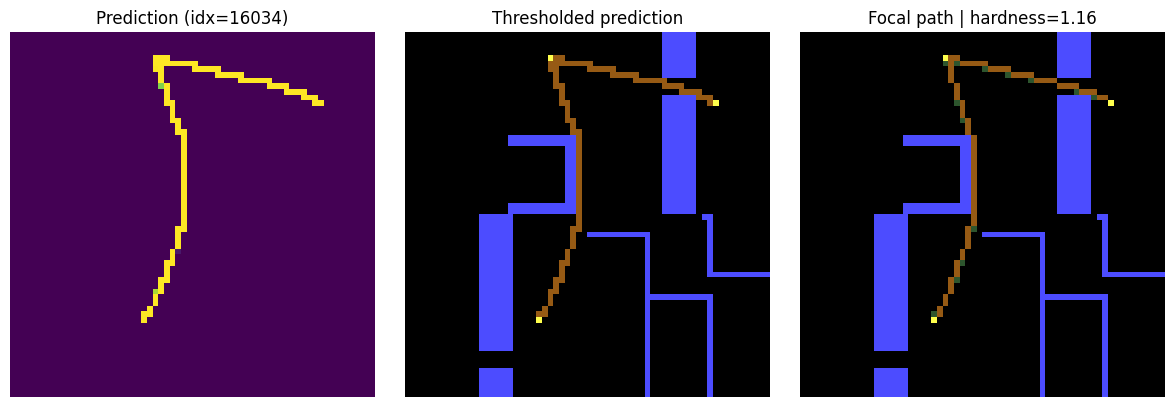

torch.Size([1, 64, 64])
torch.Size([1, 64, 64])


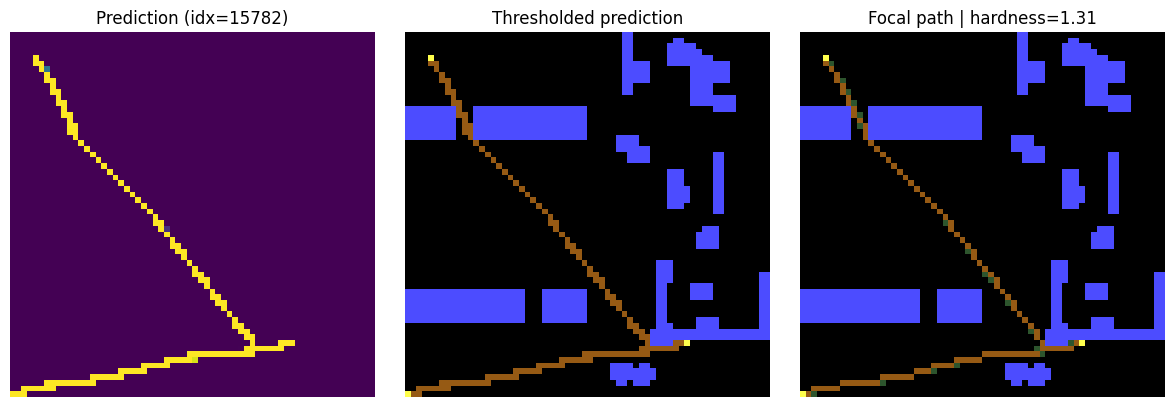

torch.Size([1, 64, 64])


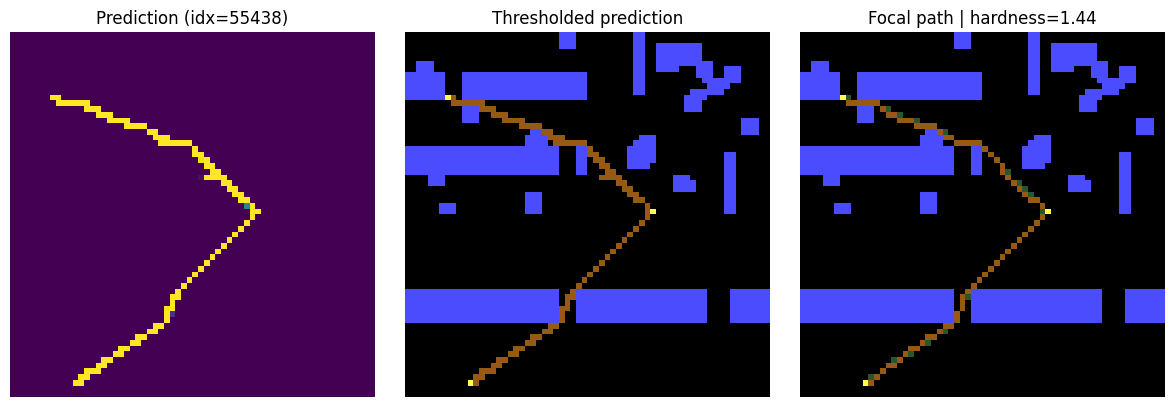

torch.Size([1, 64, 64])


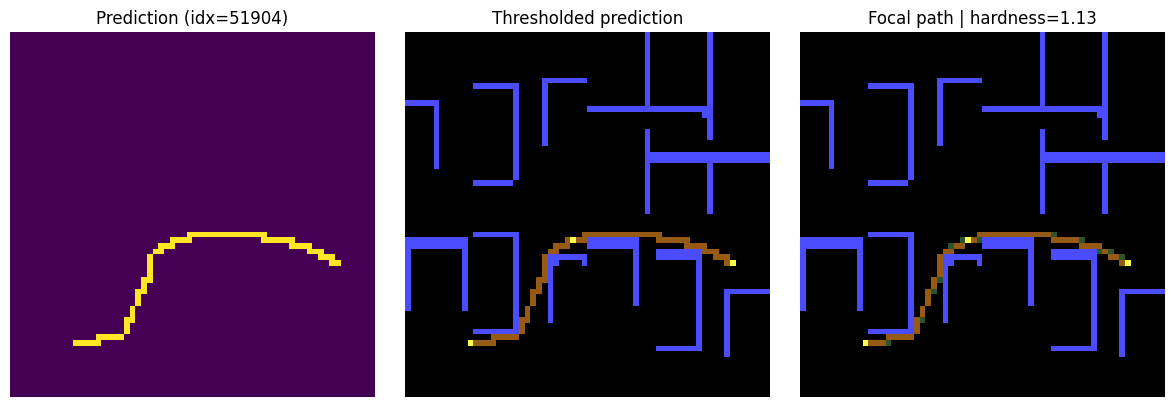

torch.Size([1, 64, 64])


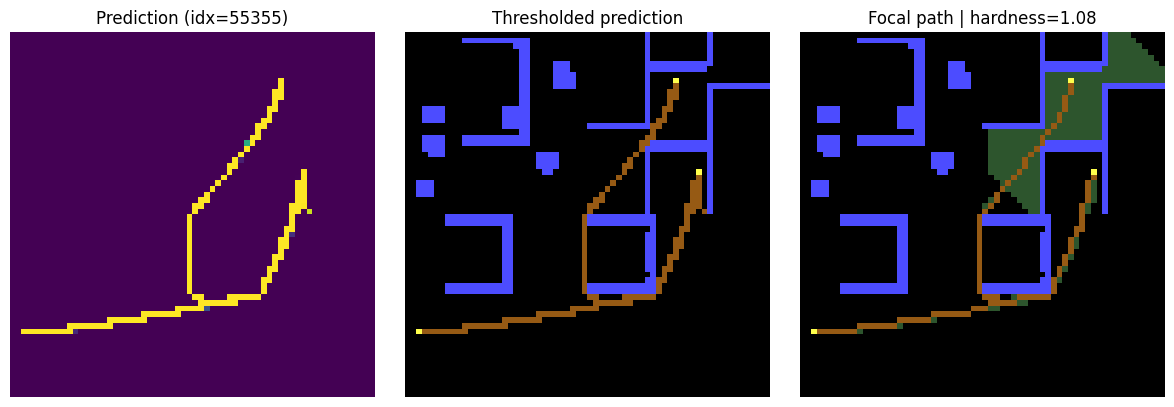

torch.Size([1, 64, 64])
torch.Size([1, 64, 64])


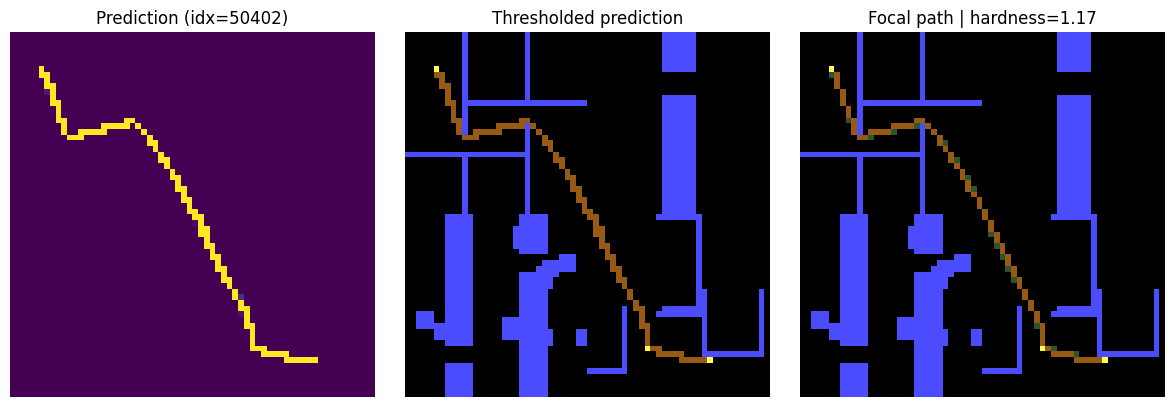

torch.Size([1, 64, 64])


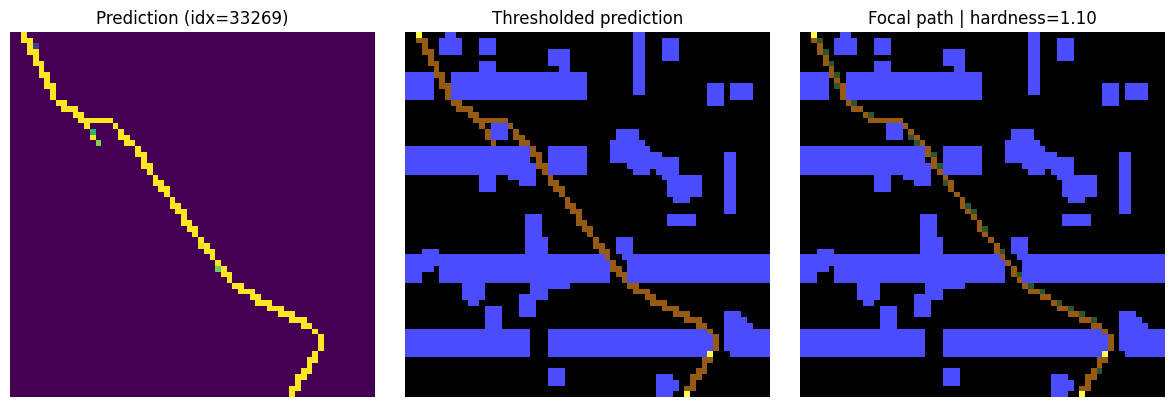

torch.Size([1, 64, 64])
torch.Size([1, 64, 64])


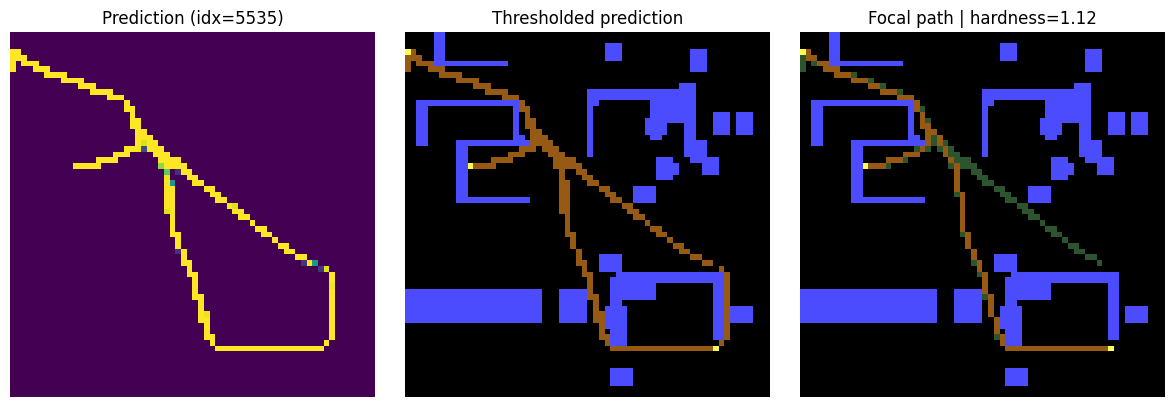

torch.Size([1, 64, 64])


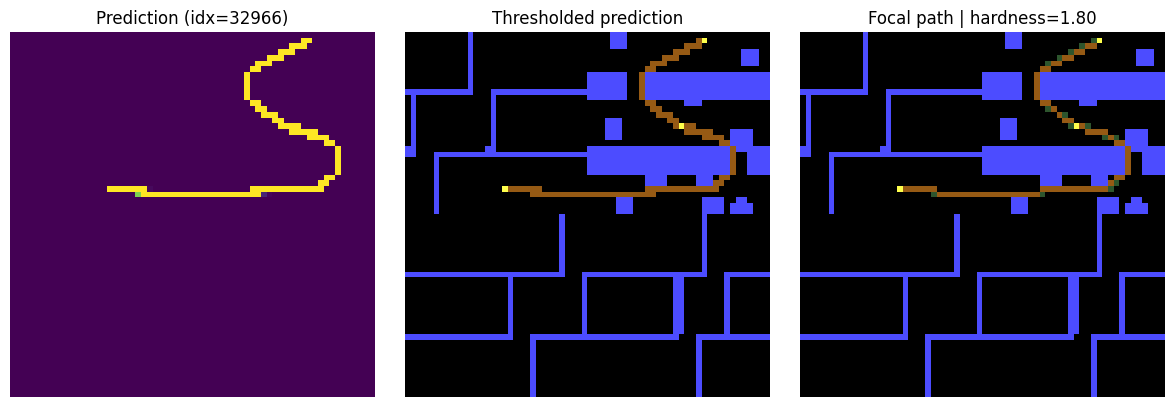

torch.Size([1, 64, 64])
torch.Size([1, 64, 64])


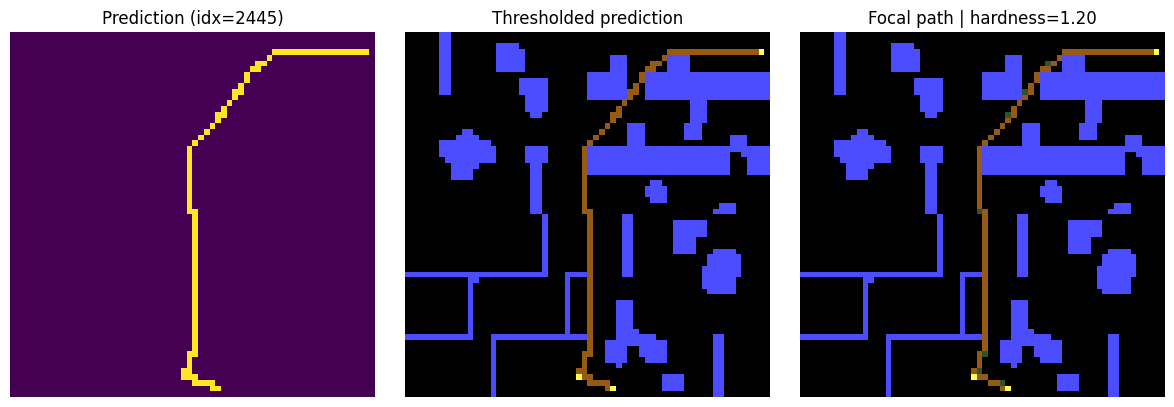

Displayed 10 samples.


In [5]:
indices = list(range(len(dataset)))
random.shuffle(indices)

shown = 0
for idx in indices:
    sample = dataset[idx]

    img_tensor = sample["images"]
    start = sample["starts"].cpu().numpy().astype(np.int64)
    end = sample["ends"].cpu().numpy().astype(np.int64)

    wp_color = torch.tensor([1.0, 1.0, 76 / 255], device=img_tensor.device)  # WP
    wp_map = torch.sigmoid((img_tensor.unsqueeze(0) - wp_color.view(3, 1, 1)).abs()).sum(1, keepdim=True)
    wp_map = (wp_map < 1.51).all(dim=1).float()  #  will have a value of 3 * sig(0.0) = 1.5, add small margin to be safe against numerical inaccuracies

    B, H, W = wp_map.shape

    print(wp_map.shape)

    # Flatten H,W dimensions
    flat_maps = wp_map.view(B, -1)  # [B, H*W]

    # Get linear indices of the '1's
    indices = flat_maps.argmax(dim=1)  # [B]

    # Convert linear index to 2D coordinates
    wp_y = (indices // W).item()
    wp_x = (indices % W).item()

    img_np = torch.clamp(img_tensor.unsqueeze(0) * 255, 0, 255).cpu().numpy()
    img_np_uint8 = img_np.astype(np.uint8).transpose(0, 2, 3, 1)
    base_rgb = img_np_uint8[0]

    obstacle_grid = binary_obstacle_from_image(img_np_uint8)[0]
    full_free = ~obstacle_grid

    _, a_star_grid_cost, _, _ = run_astar_2D(full_free, start[0], start[1], end[0], end[1])
    heuristic = max(float(octile_distance(start[0], start[1], end[0], end[1])), 1e-8)
    hardness = float(a_star_grid_cost) / heuristic
    if hardness < MIN_HARDNESS:
        continue

    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        out = model(x)

    logits_raw = _extract_logits(out)
    logits = torch.tanh(logits_raw)
    path_pred = ((logits + 1.0) / 2.0).detach().cpu().numpy()[0]
    if path_pred.ndim == 3:
        path_pred = path_pred[0]

    pred_path_mask = path_pred >= THRESHOLD
    pred_path_mask[start[0], start[1]] = True
    pred_path_mask[end[0], end[1]] = True
    pred_path_mask[np.logical_and(pred_path_mask, obstacle_grid)] = False

    focal_waypoints_1, _, _, expansion_mask_1 = run_focal_search_2D(
        full_free,
        start[0], start[1],
        wp_y, wp_x,
        w=2.0,
        path_proximity_map=(-np.copy(path_pred) + 1.0),
    )
    focal_mask_1 = _waypoints_to_mask(focal_waypoints_1, pred_path_mask.shape, start, end)

    focal_waypoints_2, _, _, expansion_mask_2 = run_focal_search_2D(
        full_free,
        wp_y, wp_x,
        end[0], end[1],
        w=2.0,
        path_proximity_map=(-np.copy(path_pred) + 1.0),
    )
    focal_mask_2 = _waypoints_to_mask(focal_waypoints_2, pred_path_mask.shape, start, end)

    focal_mask = np.logical_or(focal_mask_1, focal_mask_2)
    expansion_mask = np.logical_or(expansion_mask_1, expansion_mask_2)

    pred_rgb = swap_waypoint(_render_overlay(base_rgb, pred_path_mask, np.zeros_like(pred_path_mask), start, end, [wp_y, wp_x]), dot_lines=False)
    focal_rgb = swap_waypoint(_render_overlay(base_rgb, focal_mask, expansion_mask, start, end, [wp_y, wp_x]), dot_lines=False)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(path_pred, cmap="viridis")
    ax[0].set_title(f"Prediction (idx={idx})")
    ax[1].imshow(pred_rgb)
    ax[1].set_title("Thresholded prediction")
    ax[2].imshow(focal_rgb)
    ax[2].set_title(f"Focal path | hardness={hardness:.2f}")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

    shown += 1
    if shown >= NUM_SAMPLES:
        break

print(f"Displayed {shown} samples.")